Plotting 1/8: Team win % bat first vs chase...


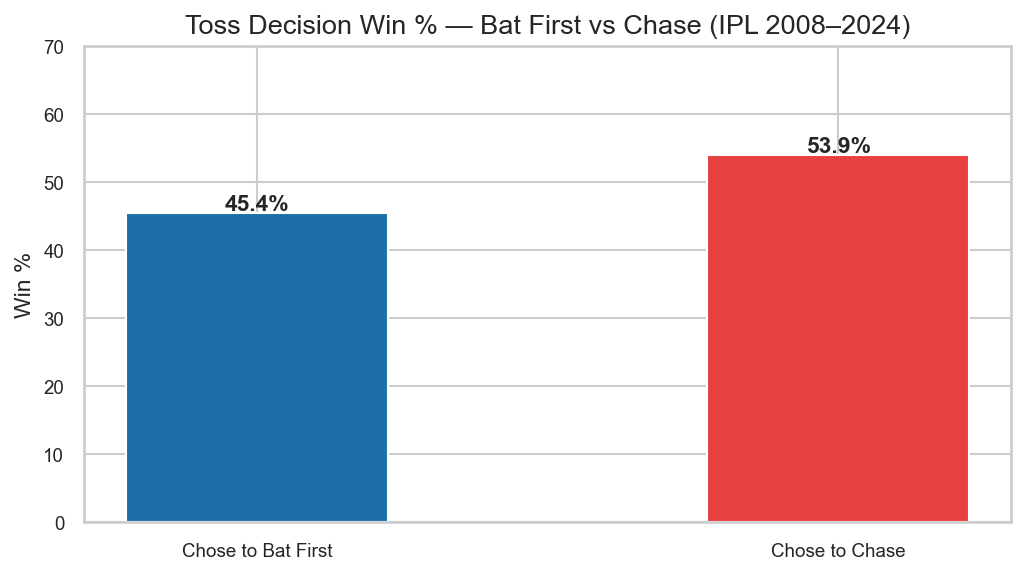

 Saved: 01_toss_win_pct.png
Plotting 2/8: Top 10 run scorers...


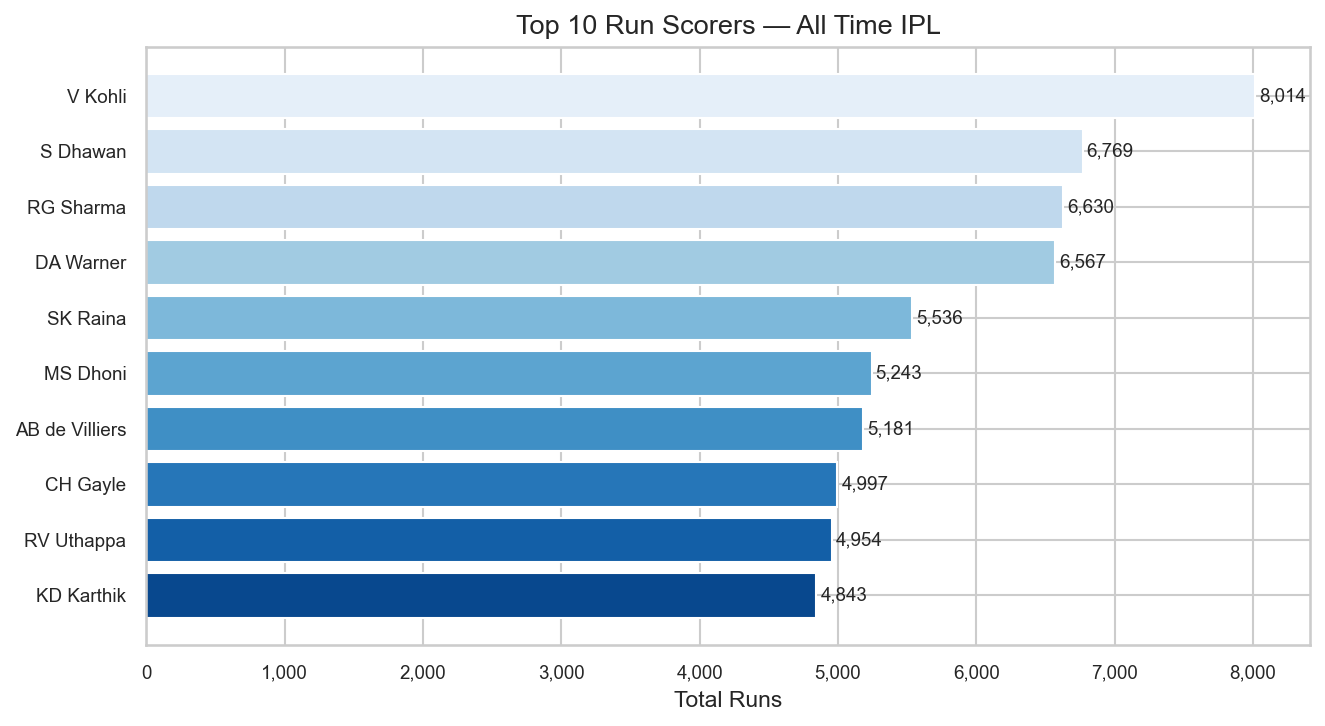

 Saved: 02_top_run_scorers.png
Plotting 3/8: Top 10 wicket takers...


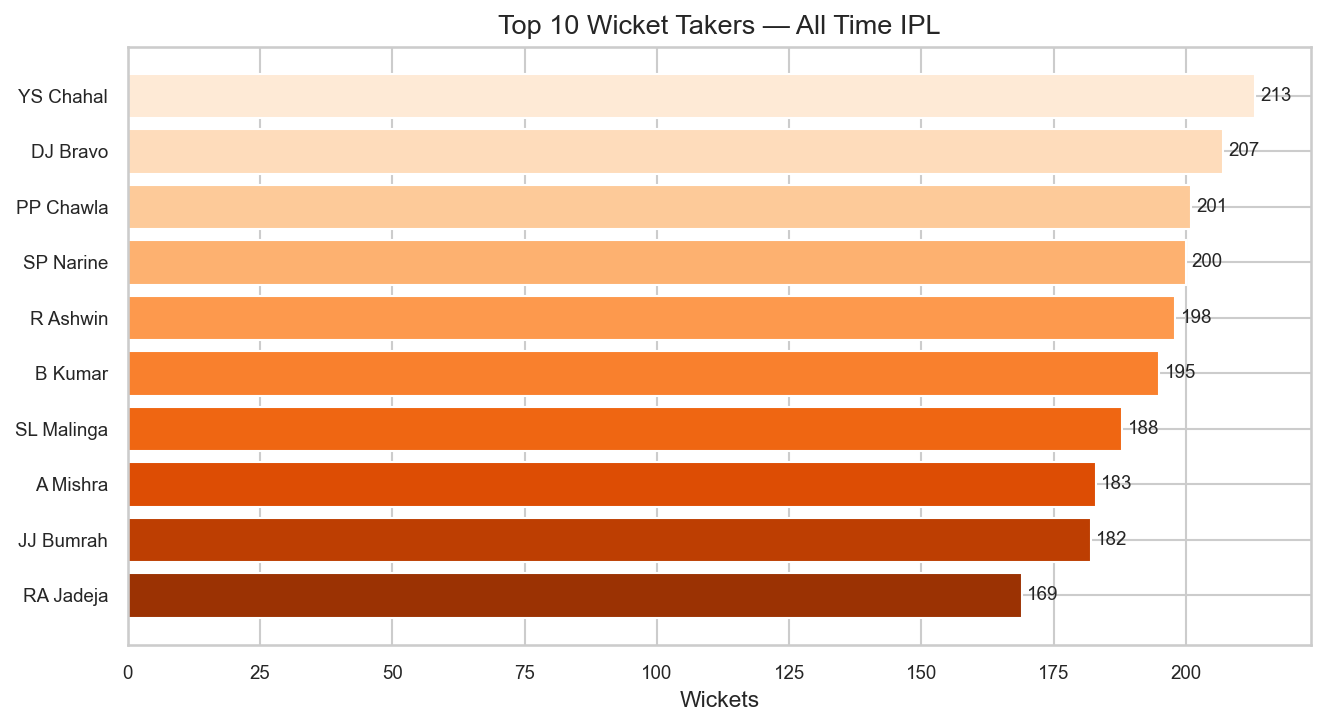

 Saved: 03_top_wicket_takers.png
Plotting 4/8: Phase-wise distribution...


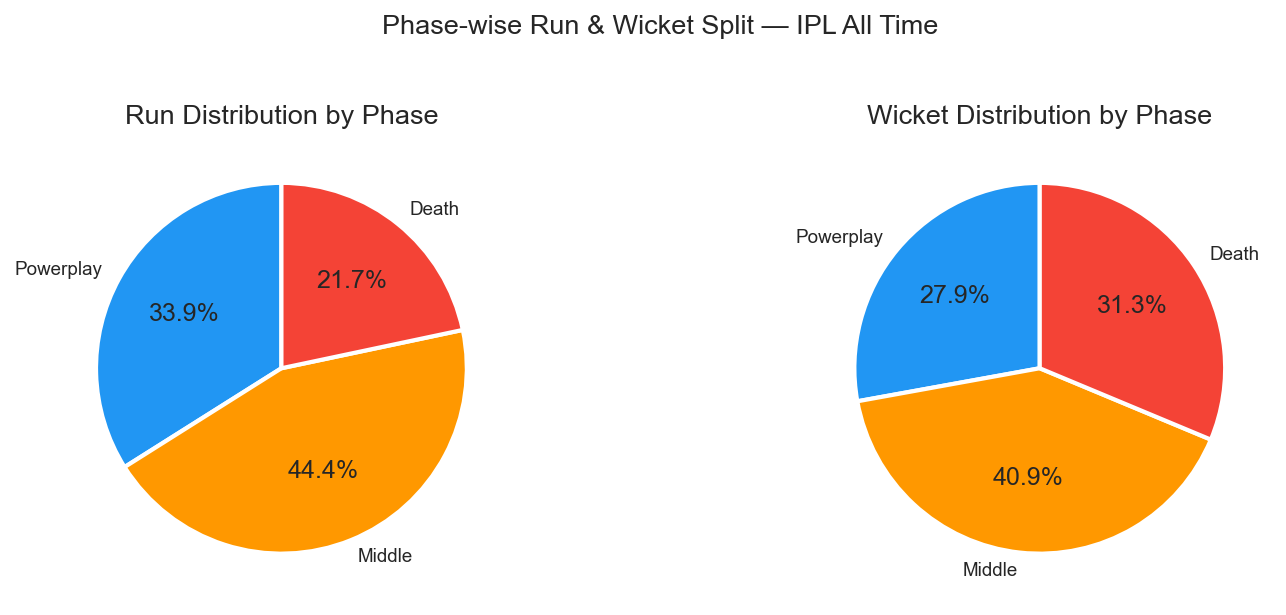

 Saved: 04_phase_distribution.png
Plotting 5/8: Season runs trend...


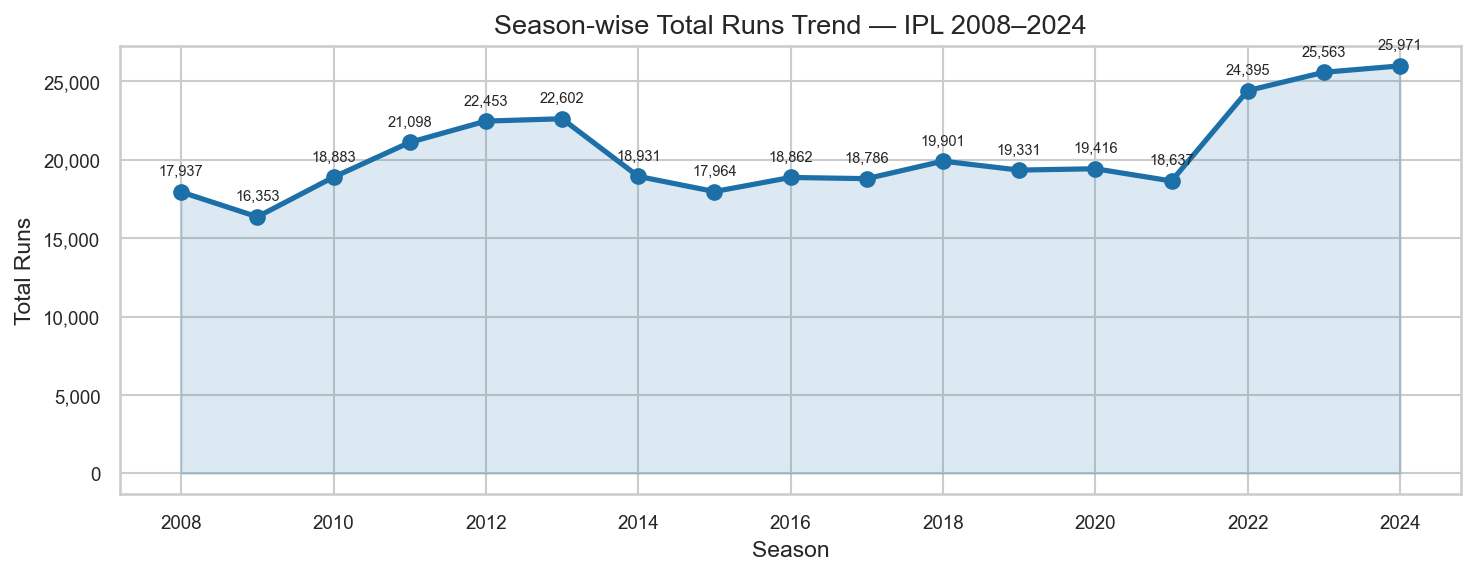

 Saved: 05_season_runs_trend.png
Plotting 6/8: Venue average score...


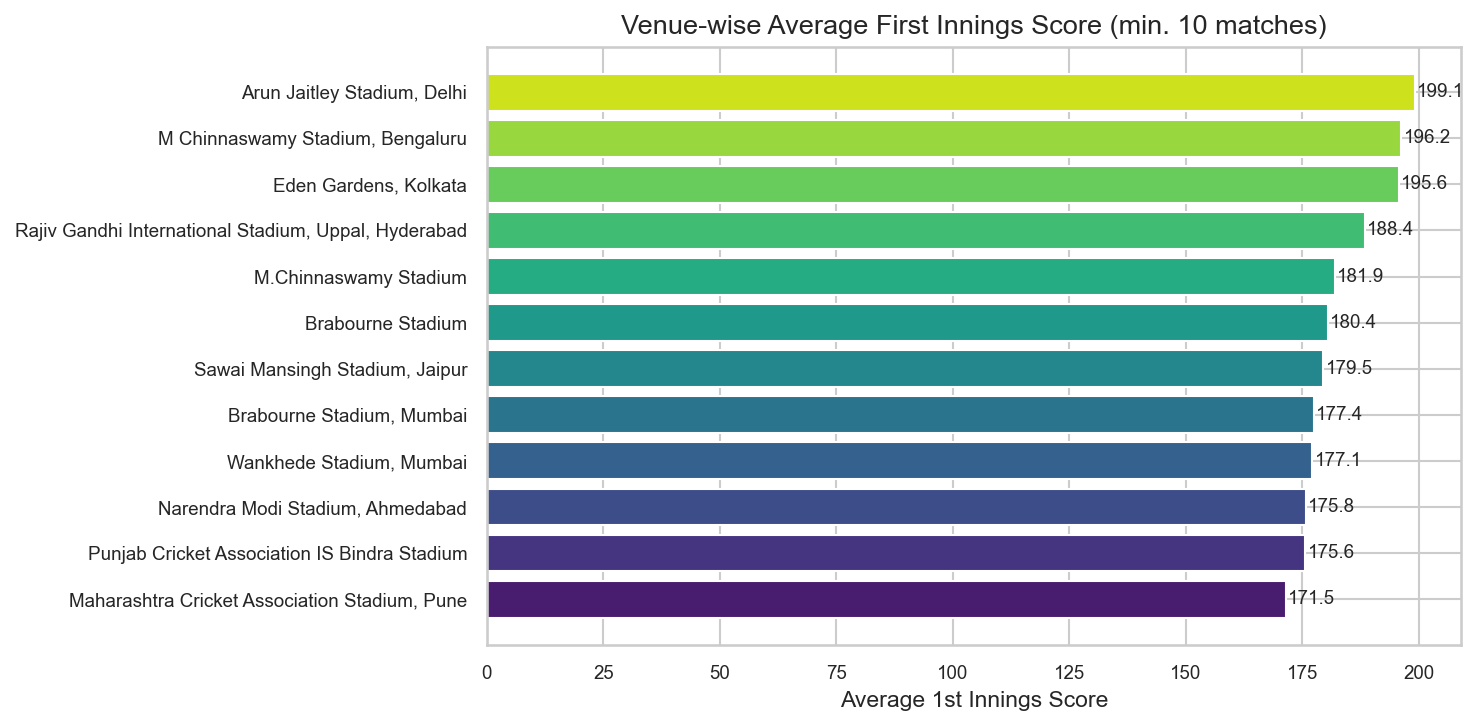

 Saved: 06_venue_avg_score.png
Plotting 7/8: Death over economy...


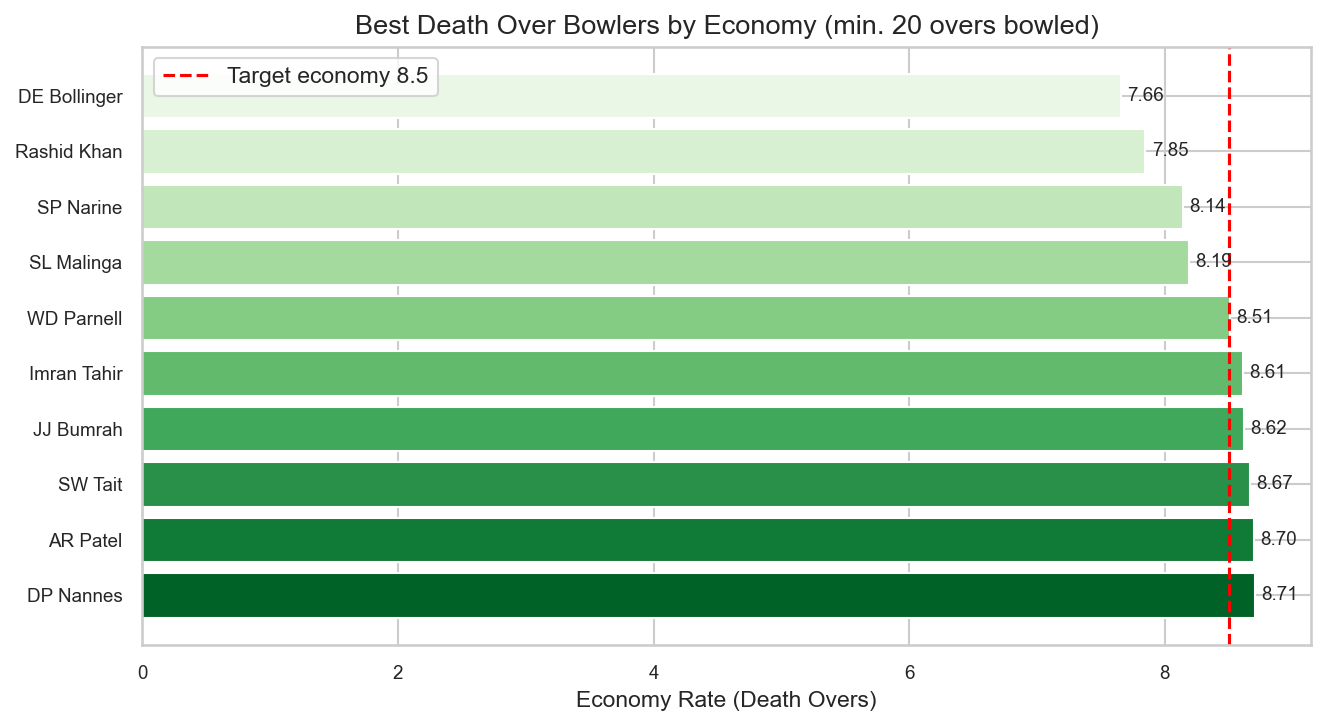

 Saved: 07_death_over_economy.png
Plotting 8/8: Team win % overall...


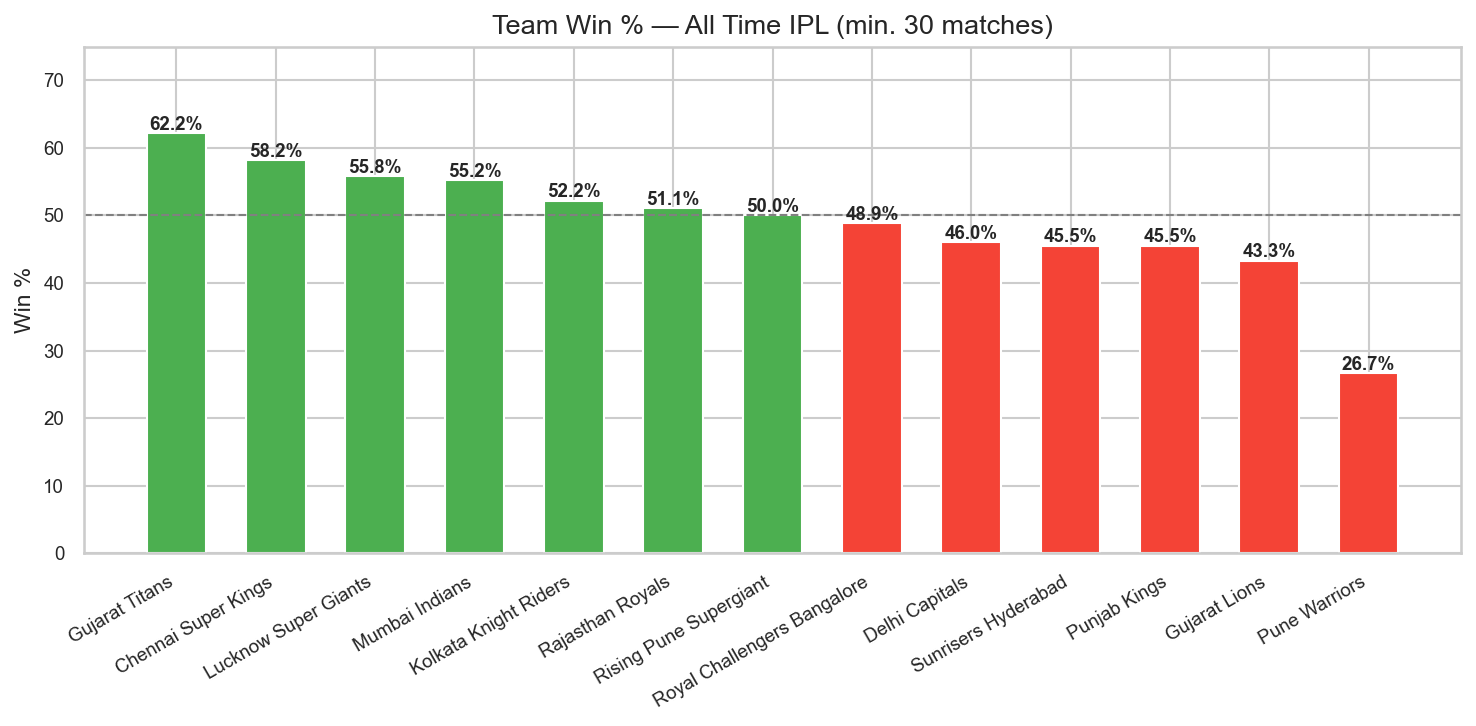

 Saved: 08_team_win_pct.png

 All 8 EDA plots saved to screenshots/


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
os.makedirs('../screenshots', exist_ok=True)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.dpi'      : 150,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
})
df_matches = pd.read_csv('../data/matches_clean.csv')
df_del     = pd.read_csv('../data/deliveries_featured.csv')
phase_df   = pd.read_csv('../data/phase_summary.csv')
print("Plotting 1/8: Team win % bat first vs chase...")
bat_first = df_matches[df_matches['toss_decision'] == 'bat'].copy()
field_first = df_matches[df_matches['toss_decision'] == 'field'].copy()
bat_wins   = (bat_first['toss_winner'] == bat_first['winner']).mean() * 100
chase_wins = (field_first['toss_winner'] == field_first['winner']).mean() * 100
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Chose to Bat First', 'Chose to Chase'], 
              [bat_wins, chase_wins],
              color=['#1D6FA8', '#E84040'], width=0.45, edgecolor='white')
for bar, val in zip(bars, [bat_wins, chase_wins]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax.set_ylim(0, 70)
ax.set_ylabel('Win %')
ax.set_title('Toss Decision Win % — Bat First vs Chase (IPL 2008–2024)')
plt.tight_layout()
plt.savefig('../screenshots/01_toss_win_pct.png', bbox_inches='tight')
plt.show()
print(" Saved: 01_toss_win_pct.png")
print("Plotting 2/8: Top 10 run scorers...")
top_batsmen = (
    df_del.groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_batsmen.columns = ['Batsman', 'Total Runs']
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_batsmen['Batsman'][::-1], top_batsmen['Total Runs'][::-1],
               color=sns.color_palette('Blues_r', 10), edgecolor='white')
for bar, val in zip(bars, top_batsmen['Total Runs'][::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=9)
ax.set_xlabel('Total Runs')
ax.set_title('Top 10 Run Scorers — All Time IPL')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../screenshots/02_top_run_scorers.png', bbox_inches='tight')
plt.show()
print(" Saved: 02_top_run_scorers.png")
print("Plotting 3/8: Top 10 wicket takers...")
top_bowlers = (
    df_del[df_del['player_dismissed'] != 'not_out']
    .groupby('bowler')['player_dismissed']
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_bowlers.columns = ['Bowler', 'Wickets']
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_bowlers['Bowler'][::-1], top_bowlers['Wickets'][::-1],
               color=sns.color_palette('Oranges_r', 10), edgecolor='white')
for bar, val in zip(bars, top_bowlers['Wickets'][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontsize=9)
ax.set_xlabel('Wickets')
ax.set_title('Top 10 Wicket Takers — All Time IPL')
plt.tight_layout()
plt.savefig('../screenshots/03_top_wicket_takers.png', bbox_inches='tight')
plt.show()
print(" Saved: 03_top_wicket_takers.png")
print("Plotting 4/8: Phase-wise distribution...")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
phases = ['Powerplay', 'Middle', 'Death']
phase_df_sorted = phase_df.set_index('phase').loc[phases].reset_index()
colors = ['#2196F3', '#FF9800', '#F44336']
axes[0].pie(phase_df_sorted['total_runs'], labels=phases,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[0].set_title('Run Distribution by Phase')
axes[1].pie(phase_df_sorted['total_wickets'], labels=phases,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[1].set_title('Wicket Distribution by Phase')
plt.suptitle('Phase-wise Run & Wicket Split — IPL All Time', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/04_phase_distribution.png', bbox_inches='tight')
plt.show()
print(" Saved: 04_phase_distribution.png")
print("Plotting 5/8: Season runs trend...")
season_runs = (
    df_del.groupby('season')['total_runs']
    .sum()
    .reset_index()
)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(season_runs['season'], season_runs['total_runs'],
        marker='o', linewidth=2.5, color='#1D6FA8', markersize=7)
ax.fill_between(season_runs['season'], season_runs['total_runs'],
                alpha=0.15, color='#1D6FA8')
for _, row in season_runs.iterrows():
    ax.annotate(f"{int(row['total_runs']):,}", 
                (row['season'], row['total_runs']),
                textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=7)
ax.set_xlabel('Season')
ax.set_ylabel('Total Runs')
ax.set_title('Season-wise Total Runs Trend — IPL 2008–2024')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../screenshots/05_season_runs_trend.png', bbox_inches='tight')
plt.show()
print(" Saved: 05_season_runs_trend.png")
print("Plotting 6/8: Venue average score...")
first_innings = df_matches[['id', 'venue']].merge(
    df_del[df_del['inning'] == 1].groupby('match_id')['total_runs'].sum().reset_index(),
    left_on='id', right_on='match_id', how='inner'
)
venue_avg = (
    first_innings.groupby('venue')['total_runs']
    .agg(['mean', 'count'])
    .reset_index()
)
venue_avg.columns = ['venue', 'avg_score', 'matches']
venue_avg = venue_avg[venue_avg['matches'] >= 10].sort_values('avg_score', ascending=False).head(12)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(venue_avg['venue'][::-1], venue_avg['avg_score'][::-1],
               color=sns.color_palette('viridis', len(venue_avg)), edgecolor='white')
for bar, val in zip(bars, venue_avg['avg_score'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
ax.set_xlabel('Average 1st Innings Score')
ax.set_title('Venue-wise Average First Innings Score (min. 10 matches)')
plt.tight_layout()
plt.savefig('../screenshots/06_venue_avg_score.png', bbox_inches='tight')
plt.show()
print(" Saved: 06_venue_avg_score.png")
print("Plotting 7/8: Death over economy...")
death_del = df_del[df_del['phase'] == 'Death'].copy()
death_del['is_legal'] = death_del['extras_type'].apply(
    lambda x: 0 if str(x) in ['wides', 'noballs'] else 1
)
death_bowlers = death_del.groupby('bowler').agg(
    runs    = ('total_runs', 'sum'),
    balls   = ('is_legal', 'sum'),
    wickets = ('is_wicket', 'sum')
).reset_index()
death_bowlers = death_bowlers[death_bowlers['balls'] >= 120]   # min 20 overs
death_bowlers['economy'] = (death_bowlers['runs'] / (death_bowlers['balls'] / 6)).round(2)
best_death = death_bowlers.sort_values('economy').head(10)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(best_death['bowler'][::-1], best_death['economy'][::-1],
               color=sns.color_palette('Greens_r', 10), edgecolor='white')
for bar, val in zip(bars, best_death['economy'][::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
ax.axvline(x=8.5, color='red', linestyle='--', linewidth=1.5, label='Target economy 8.5')
ax.set_xlabel('Economy Rate (Death Overs)')
ax.set_title('Best Death Over Bowlers by Economy (min. 20 overs bowled)')
ax.legend()
plt.tight_layout()
plt.savefig('../screenshots/07_death_over_economy.png', bbox_inches='tight')
plt.show()
print(" Saved: 07_death_over_economy.png")
print("Plotting 8/8: Team win % overall...")
team_matches = pd.concat([df_matches['team1'], df_matches['team2']]).value_counts()
team_wins    = df_matches['winner'].value_counts()
team_stats   = pd.DataFrame({'matches': team_matches, 'wins': team_wins}).dropna()
team_stats['win_pct'] = (team_stats['wins'] / team_stats['matches'] * 100).round(1)
team_stats   = team_stats[team_stats['matches'] >= 30].sort_values('win_pct', ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#4CAF50' if w >= 50 else '#F44336' for w in team_stats['win_pct']]
bars = ax.bar(team_stats.index, team_stats['win_pct'], color=colors_bar, edgecolor='white', width=0.6)
for bar, val in zip(bars, team_stats['win_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=9, fontweight='bold')
ax.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='50% line')
ax.set_ylabel('Win %')
ax.set_ylim(0, 75)
ax.set_title('Team Win % — All Time IPL (min. 30 matches)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../screenshots/08_team_win_pct.png', bbox_inches='tight')
plt.show()
print(" Saved: 08_team_win_pct.png")
print("\n All 8 EDA plots saved to screenshots/")